# Verificación de calidad de los datos del SIMA

**Issue #11.** Auditoría del consolidado `data/processed/sima_horario.parquet`
(688,184 observaciones horarias, 2020-01-01 a 2025-06-30, 15 estaciones).

No se limpió nada, solamente se dieron insights. 

## Qué ya estaba verificado

La issue #9 dejó documentado en [`data/README.md`](../data/README.md):

- El porcentaje de faltantes por parámetro (de 3.7 % en `SR` a 24.6 % en `PM2.5`).
- Sin fechas nulas y sin pares `(estación, fecha)` duplicados.
- Cobertura temporal continua, sin huecos de días completos.
- Las **23 banderas de calidad** de `Etiquetas.xlsx` no aparecen en ninguno de los
  archivos entregados: se revisaron las 87 hojas de los seis libros y no hay una sola
  celda con letra de bandera.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# El notebook puede ejecutarse con el cwd en notebooks/ o en la raiz del repo,
# segun como lo lance el editor. Esto lo resuelve en los dos casos.
RAIZ = Path.cwd()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent
RUTA_PROCESSED = RAIZ / "data" / "processed"

# Columnas que identifican la observacion; el resto son mediciones.
LLAVES = ["fecha", "estacion", "anio"]

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

sima = pd.read_parquet(RUTA_PROCESSED / "sima_horario.parquet")
PARAMETROS = [c for c in sima.columns if c not in LLAVES]

print(f"filas x columnas : {sima.shape[0]:,} x {sima.shape[1]}")
print(f"cobertura        : {sima['fecha'].min()} -> {sima['fecha'].max()}")
print(f"estaciones       : {sima['estacion'].nunique()}")
print(f"parametros       : {len(PARAMETROS)}")

filas x columnas : 688,184 x 18
cobertura        : 2020-01-01 00:00:00 -> 2025-06-30 23:00:00
estaciones       : 15
parametros       : 15


## 1. Cuántas observaciones aporta cada estación

La rejilla temporal tiene **48,192 horas** (2,008 días × 24). Si las 15 estaciones
hubieran reportado siempre, habría 722,880 filas; hay 688,184. Pero no es ruido, solo dice cuándo entró en operación cada estación y dónde faltan renglones enteros.

In [2]:
sima['estacion'].value_counts()

estacion
CE      48190
SE      48183
NO      48181
NE      48180
NTE     48180
NO2     48179
SE2     48179
NTE2    48178
SE3     48178
SO2     48178
NE2     48177
SUR     48176
SO      48041
NE3     39378
NO3     22606
Name: count, dtype: int64

**IMPORTANTE: hay huecos que no son nulos, son renglones enteros ausentes.**

Dos estaciones entraron en operación tarde, que son: `NE3` y `NO3`. Lo que explica la diferencia que hay. 39,378 horas (arranca en 2021) y solo 22,606 (arranca a media hoja de
2022, como ya documentaba `data/README.md`).

Pero el resto de las estaciones tampoco llega a las 48,192 horas: `SO` se queda en
48,041 —le faltan **151 renglones**— y las demás pierden entre 2 y 16. Eso es una
categoría de faltante distinta a la que mide `pct_nulo`:

> Un renglón ausente **no aparece como nulo**, porque la fila no existe. El porcentaje
> de nulos de la sección siguiente se calcula sobre las filas que sí están, así que
> no es lo mismo del faltante real.

## 2. Nulos y tipos por columna

In [3]:
resumen = pd.DataFrame(
    {
        "tipo": sima.dtypes.astype(str),
        "n_nulos": sima.isna().sum(),
        "pct_nulo": (sima.isna().mean() * 100).round(2),
        "n_distintos": sima.nunique(dropna=True),
    }
)
resumen.index.name = "columna"
resumen

,tipo,n_nulos,pct_nulo,n_distintos
columna,,,,
fecha,datetime64[us],0,0.00,48192
estacion,category,0,0.00,15
anio,int64,0,0.00,6
CO,float64,90860,13.20,1947
NO,float64,120713,17.54,2663
NO2,float64,126331,18.36,1261
NOX,float64,120933,17.57,3031
O3,float64,106097,15.42,998
PM10,float64,31098,4.52,12903


### Cómo leer esta tabla

- **Las tres llaves no tienen nulos.** Las tres variables identificadoras no tienen ningún nulo, que es la condición mínima para poder cruzar o agregar. 
- **Todos los parámetros son `float64`.** PERO leer la nota al final de esta sección.
- **`n_distintos` marca la resolución del instrumento.** Un parámetro con pocos valores
  distintos sobre cientos de miles de filas está reportando en escalones, no en
  continuo.

### Los faltantes en el tiempo

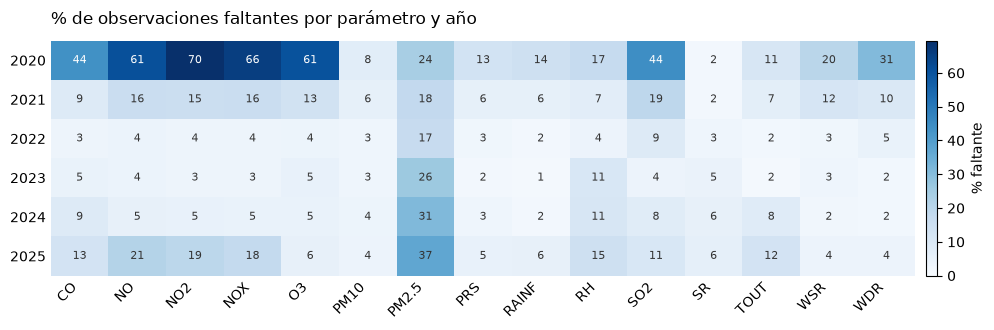

In [4]:
nulos_anio = (
    sima.set_index("anio")[PARAMETROS].isna().groupby(level=0).mean().mul(100)
)

fig, ax = plt.subplots(figsize=(11, 3.4))

# Rampa secuencial de un solo tono: el dato es magnitud (% faltante), no identidad.
# La escala arranca en 0 y termina en el maximo observado; fijarla en 100 dejaria
# todas las celdas casi blancas y el patron no se veria. El numero exacto va escrito
# en cada celda, asi que al color le basta con ordenar.
tope = float(nulos_anio.to_numpy().max())
malla = ax.imshow(nulos_anio, cmap="Blues", vmin=0, vmax=tope, aspect="auto")

ax.set_xticks(range(len(PARAMETROS)), PARAMETROS, rotation=45, ha="right")
ax.set_yticks(range(len(nulos_anio)), nulos_anio.index)
ax.set_title("% de observaciones faltantes por parámetro y año", pad=12, loc="left")

# El valor va escrito en cada celda: el color ordena, el número precisa.
for i in range(nulos_anio.shape[0]):
    for j in range(nulos_anio.shape[1]):
        pct = nulos_anio.iat[i, j]
        ax.text(
            j, i, f"{pct:.0f}",
            ha="center", va="center", fontsize=8,
            color="white" if pct > 0.55 * tope else "#333333",
        )

for lado in ax.spines.values():
    lado.set_visible(False)
ax.tick_params(length=0)
fig.colorbar(malla, ax=ax, label="% faltante", pad=0.01)
fig.tight_layout()
plt.show()

### ⚠️ Un nulo no siempre fue un nulo

Hallazgo importante para interpretar todo lo anterior. En
[`src/importar_datos.py`](../src/importar_datos.py) la conversión a número se hace así:

```python
hoja[parametro] = pd.to_numeric(hoja[parametro], errors="coerce")
```

`errors="coerce"` convierte **a nulo, y en silencio, todo lo que no sea numérico**. Es
la decisión correcta para consolidar (si no, el script truena con la primera celda
rara), pero tiene una consecuencia directa para esta auditoría:

> Una parte de los nulos contados arriba **no eran celdas vacías en el origen**: eran
> texto que no se pudo convertir.

La issue #11 pide reportar específicamente *texto donde debería haber número*, y eso
**no se puede auditar desde `processed/`** — ahí la evidencia ya se perdió. Hay que ir
a `data/raw/`. Queda pendiente para la sección siguiente del notebook.

## 3. Valores fuera del rango físico

Fuente: [`docs/Rangos de los parámetros del SIMA.pdf`](../docs/). Define dos criterios:

- **Operación** — lo que SIMA considera plausible. Cambia año con año. Salirse es *sospechoso*.
- **Fabricante** — lo que el sensor puede reportar. Salirse es *imposible*.

El PDF nombra cinco parámetros distinto al parquet: `NOx`→`NOX`, `WS`→`WSR`,
`TEMP`→`TOUT`, `BP`→`PRS`, `WD`→`WDR`.

In [5]:
ANIOS = [2020, 2021, 2022, 2023, 2024, 2025]
TRADUCE = {"NOx": "NOX", "WS": "WSR", "TEMP": "TOUT", "BP": "PRS", "WD": "WDR"}

# Rango de operación: un (min, max) por año, en el orden de ANIOS.
OPERACION = {
    "PM10":  [(0, 800), (0, 800), (0, 999), (0, 900), (0, 999), (0, 820)],
    "PM2.5": [(0, 205.94), (0, 325), (0, 450), (0, 800), (0, 999), (0, 350)],
    "O3":    [(0, 153), (0, 175), (0, 160), (0, 175), (0, 180), (0, 185)],
    "NO":    [(0, 500), (0, 350), (0, 400), (0, 500), (0, 400), (0, 350)],
    "NO2":   [(0, 200), (0, 100), (0, 175), (0, 175), (0, 130), (0, 175)],
    "NOx":   [(0, 500), (0, 400), (0, 420), (0, 500), (0, 500), (0, 400)],
    "SO2":   [(0, 200), (0, 300), (0, 200), (0, 250), (0, 150), (0, 405)],
    "CO":    [(0, 20), (0, 10), (0, 8), (0, 14), (0, 18), (0, 10)],
    "RH":    [(0, 100)] * 6,
    "WS":    [(0, 75), (0, 40), (0, 35), (0, 40), (0, 38), (0, 40)],
    "TEMP":  [(0, 41), (-6.5, 45), (-5, 45), (0, 45), (-4, 45.5), (-4.5, 45)],
    "SR":    [(0, 1), (0, 1), (0, 1.25), (0, 1), (0, 1.26), (0, 1.2)],
    "BP":    [(690, 750), (690, 740), (700, 740), (690, 740), (687.5, 740), (688, 740)],
    "WD":    [(0, 360)] * 6,
    "RAINF": [(0, 30), (0, 80), (0, 25), (0, 70), (0, 50), (0, 25)],
}

# Rango del fabricante: fijo. RAINF no tiene (el PDF solo dice "conteo pulso 0.01").
FABRICANTE = {
    "PM10": (0, 1000), "PM2.5": (0, 1000), "O3": (0, 1000),
    "NO": (0, 500), "NO2": (0, 500), "NOx": (0, 500), "SO2": (0, 500),
    "CO": (0, 50), "RH": (0, 100), "WS": (0, 180), "TEMP": (-50, 50),
    "SR": (0, 1.4), "BP": (449.9, 824.9), "WD": (0, 360),
}


def cuenta_fuera_operacion():
    """Observaciones fuera del rango de SU año, por parámetro y año."""
    filas = {}
    for nombre, tramos in OPERACION.items():
        col = TRADUCE.get(nombre, nombre)
        filas[col] = {}
        for anio, (bajo, alto) in zip(ANIOS, tramos):
            valores = sima.loc[sima["anio"] == anio, col]
            filas[col][anio] = int(((valores < bajo) | (valores > alto)).sum())
    return pd.DataFrame(filas).T


fuera_op = cuenta_fuera_operacion()
fuera_op["TOTAL"] = fuera_op.sum(axis=1)
fuera_op.sort_values("TOTAL", ascending=False)

,2020,2021,2022,2023,2024,2025,TOTAL
PRS,101,429,6305,486,405,362,8088
WSR,6,1184,126,360,24,0,1700
SR,1,45,717,180,151,7,1101
TOUT,450,16,2,9,40,0,517
RH,0,3,155,95,25,0,278
CO,0,22,0,1,2,0,25
NOX,0,5,11,0,0,0,16
NO,0,5,8,0,2,0,15
O3,1,5,0,0,2,0,8
RAINF,0,6,0,0,2,0,8


In [6]:
# Fuera del rango del FABRICANTE: valores que el sensor no puede haber medido.
for nombre, (bajo, alto) in FABRICANTE.items():
    col = TRADUCE.get(nombre, nombre)
    fuera = sima.loc[(sima[col] < bajo) | (sima[col] > alto), ["fecha", "estacion", col]]
    if fuera.empty:
        continue
    print(f"{col}: {len(fuera):,} observaciones fuera de [{bajo}, {alto}]"
          f"  (min {fuera[col].min()}, max {fuera[col].max()})")
    print(fuera.nlargest(3, col).to_string(index=False), "\n")

PM10: 1 observaciones fuera de [0, 1000]  (min 1001.0, max 1001.0)
              fecha estacion   PM10
2022-12-18 05:00:00      NTE 1001.0 

PM2.5: 1 observaciones fuera de [0, 1000]  (min -1.0, max -1.0)
              fecha estacion  PM2.5
2024-12-07 06:00:00      SE3   -1.0 

O3: 1 observaciones fuera de [0, 1000]  (min -9.0, max -9.0)
              fecha estacion   O3
2024-09-17 13:00:00     NTE2 -9.0 

NO: 11 observaciones fuera de [0, 500]  (min 515.8, max 945.1)
              fecha estacion    NO
2022-03-15 12:00:00       NO 945.1
2022-01-04 11:00:00       NO 895.2
2022-03-15 13:00:00       NO 858.6 

NOX: 12 observaciones fuera de [0, 500]  (min 524.6, max 971.8)
              fecha estacion   NOX
2022-03-15 12:00:00       NO 971.8
2022-01-04 11:00:00       NO 897.0
2022-03-15 11:00:00       NO 874.9 

CO: 1 observaciones fuera de [0, 50]  (min -0.01, max -0.01)
              fecha estacion    CO
2024-12-29 05:00:00      SO2 -0.01 

RH: 278 observaciones fuera de [0, 100]  (min 

In [7]:
# -9999 no es una medición: es el código de "sin dato" del sensor.
# Sobrevivió a la importación porque es un número válido y to_numeric lo aceptó.
centinelas = {}
for col in PARAMETROS:
    for valor in (-9999, -999, -99):
        n = int((sima[col] == valor).sum())
        if n:
            centinelas[(col, valor)] = n

pd.Series(centinelas, name="n_observaciones").rename_axis(["parametro", "centinela"])

parametro  centinela
RH         -9999         2
SR         -9999        11
TOUT       -9999         1
Name: n_observaciones, dtype: int64

### Hallazgos de la sección 3

**`-9999` es un código de "sin dato", no una medición.** Aparece como mínimo de `RH`,
`TOUT` y `SR`. Entró al parquet como número real, así que **cualquier media o desviación
calculada sin quitarlo sale disparatada**. Es el hallazgo más accionable para la #13.

**Fuera del rango de operación** (11,762 observaciones, sospechosas):

| | total | se concentra en |
|---|---|---|
| `PRS` | 8,088 | 2022 (6,305) |
| `WSR` | 1,700 | 2021 (1,184) |
| `SR` | 1,101 | 2022 (717) |
| `TOUT` | 517 | 2020 (450) |
| `RH` | 278 | 2022 (155) |

**Fuera del rango del fabricante** (imposibles, 1757 en total): `SR` 1,007 · `TOUT` 405 · `RH` 278 · `WSR` 39 · `NOX` 12 · `NO` 11, más una observación suelta en `PM10`, `PM2.5`, `O3`, `CO` y `PRS`. `WDR` y `NO2` salen limpios.

**Sospecha de unidades en `SR`.** Llega a 501 cuando el tope del sensor es 1.4 kW/m².
501 W/m² es radiación solar normal, así que parte de las lecturas parecen venir en
W/m² y no en kW/m². Hay que confirmarlo con SIMA antes de afirmarlo.

**Las fallas son por estación, no por sensor.** `2020-11-10 19:00` en `SE` tiene `SR=64`
y `PRS=0.0` a la vez; `NO` y `NOX` comparten los mismos timestamps del 2022-03-15 en la
estación `NO`. Conviene descartar la observación completa, no el valor suelto.

## 4. ¿Hay texto donde debería haber número?

La sección 2 dejó esta duda abierta: `to_numeric(..., errors="coerce")` manda a nulo
cualquier celda no numérica **sin avisar**. Para saber cuánto se perdió hay que ir a
`data/raw/` y leer las celdas tal cual llegaron.

> Esta celda relee los seis Excel. Tarda unos 3 minutos.

In [8]:
import sys

if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

# Se reutilizan las funciones de la importación para leer los Excel EXACTAMENTE
# igual que ella; si se replicaran aquí, se estaría auditando otro proceso.
from src.importar_datos import (
    ANIOS, RUTA_RAW, _normalizar_encabezado, _es_fila_de_unidades, _es_numero,
)

no_numericas = {}
for anio in ANIOS:
    hojas = pd.read_excel(RUTA_RAW / f"BD {anio}.xlsx", sheet_name=None,
                          engine="openpyxl", dtype=object)
    for estacion, hoja in hojas.items():
        hoja = hoja.rename(columns=_normalizar_encabezado)
        hoja = hoja.loc[:, [c for c in ["fecha", *PARAMETROS] if c in hoja.columns]]
        hoja = hoja[~hoja.apply(_es_fila_de_unidades, axis=1)]
        for p in PARAMETROS:
            if p not in hoja.columns:
                continue
            col = hoja[p]
            malas = col[col.notna() & ~col.map(_es_numero)]
            if len(malas):
                no_numericas[(anio, estacion.strip().upper(), p)] = list(malas.unique()[:5])

print(f"celdas no numéricas encontradas: {len(no_numericas)}")
no_numericas or "Ninguna: to_numeric no descartó ningún dato."

celdas no numéricas encontradas: 0


'Ninguna: to_numeric no descartó ningún dato.'

### Resultado: no se perdió nada

Cero celdas no numéricas en los seis archivos. El `coerce` no descartó un solo dato.

El texto sí es convertible a número. Los nulos de la sección 2 son huecos reales.

Queda descartado el error "texto donde debería haber número". El error de valor que sí
existe es el `-9999` de la sección 3. No es texto, es un número que finge ser medición.

## 5. Consistencia entre el catálogo de estaciones y los datos

In [9]:
catalogo = pd.read_csv(RUTA_PROCESSED / "etiquetas_estaciones.csv")

en_datos = set(sima["estacion"].unique())
en_catalogo = set(catalogo["Abreviatura"])

print(f"catálogo : {len(catalogo)} filas, {catalogo['Abreviatura'].nunique()} abreviaturas únicas")
print(f"datos    : {len(en_datos)} estaciones\n")
print(f"En datos y NO en catálogo : {sorted(en_datos - en_catalogo)}")
print(f"En catálogo y NO en datos : {sorted(en_catalogo - en_datos)}")
print(f"Chocan con un parámetro   : {sorted(en_catalogo & set(PARAMETROS))}\n")
print("Abreviaturas duplicadas en el catálogo:")
catalogo[catalogo["Abreviatura"].duplicated(keep=False)]

catálogo : 13 filas, 12 abreviaturas únicas
datos    : 15 estaciones

En datos y NO en catálogo : ['NE3', 'NO3', 'SUR']
En catálogo y NO en datos : []
Chocan con un parámetro   : ['NO', 'NO2', 'SO2']

Abreviaturas duplicadas en el catálogo:


,Abreviatura,Descripción,Estación,Municipio
0,SE,Sureste,La Pastora,Guadalupe
10,SE,Sur,Pueblo Serena,NaN


### Hallazgos: el catálogo está incompleto y tiene una errata

**Faltan tres estaciones.** `NE3`, `NO3` y `SUR` aparecen en los datos y no en el
catálogo. Las dos primeras son justamente las que entraron en operación en 2021 y 2022
(sección 1): el catálogo nunca se actualizó.

**`SE` está duplicada.** Dos filas distintas comparten abreviatura:

| Abreviatura | Descripción | Estación | Municipio |
|---|---|---|---|
| `SE` | Sureste | La Pastora | Guadalupe |
| `SE` | Sur | Pueblo Serena | *(vacío)* |

La segunda dice "Sur" y es casi con seguridad `SUR` — el código que sí está en los datos
y falta en el catálogo. Conviene confirmarlo con SIMA antes de darlo por hecho.

**Tres códigos de estación chocan con nombres de contaminante:** `NO`, `NO2` y `SO2` son
a la vez estación y columna del parquet. Hoy no rompe nada porque viven en dimensiones
distintas, pero cualquier `merge` o pivote que mezcle ambas los va a confundir.

**Ninguna estación del catálogo falta en los datos**, así que el problema es solo de
documentación desactualizada, no de datos huérfanos.

## 6. ¿Sirven el padrón vehicular y el inventario de emisiones?

La issue pregunta si aportan variables cruzables con el SIMA. Para cruzar hace falta una
llave común, y el SIMA solo tiene `fecha` y `estacion`.

In [10]:
padron = pd.read_parquet(RUTA_PROCESSED / "padron_vehicular.parquet")
inventario = pd.read_parquet(RUTA_PROCESSED / "inventario_nl_2018.parquet")

for nombre, tabla in [("sima_horario", sima), ("padron_vehicular", padron),
                      ("inventario_nl_2018", inventario)]:
    print(f"{nombre:<20} {tabla.shape[0]:>10,} filas   {list(tabla.columns[:6])}")

# ¿Comparten alguna llave? El único candidato es el municipio.
print("\nmunicipios en el padrón     :", padron["municipio"].nunique())
print("municipios en el inventario :", inventario["Nom_Mun"].nunique())
print("municipios en el catálogo   :", catalogo["Municipio"].nunique(),
      f"({catalogo['Municipio'].isna().sum()} estaciones sin municipio)")

sima_horario            688,184 filas   ['fecha', 'estacion', 'anio', 'CO', 'NO', 'NO2']
padron_vehicular      1,000,473 filas   ['municipio', 'marca', 'linea', 'tipo', 'modelo', 'cilindros']
inventario_nl_2018        2,816 filas   ['F_emi', 'Nom_Edo', 'CVE_Edo', 'CV_ZM', 'Nom_ZM', 'CVE_Mun']

municipios en el padrón     : 104
municipios en el inventario : 51
municipios en el catálogo   : 9 (3 estaciones sin municipio)


### Conclusión: no son cruzables a nivel de observación

Ninguna de las dos fuentes tiene fecha ni estación:

| | Granularidad | Temporalidad |
|---|---|---|
| `sima_horario` | estación × hora | 2020–2025, horaria |
| `padron_vehicular` | vehículo | **sin fecha** |
| `inventario_*_2018` | municipio × categoría de fuente | un solo año: **2018** |

El único puente posible es **municipio**, y llegar ahí exige pasar por el catálogo
(estación → municipio), que como vimos está incompleto: le faltan tres estaciones y tres
de sus trece filas traen el municipio vacío.

Aun resolviendo eso, el cruce sería débil:

- El **inventario es de 2018** y el SIMA arranca en 2020: no hay traslape temporal.
- El **padrón no tiene fecha**, así que entraría como una constante por municipio — la
  misma cifra repetida en las 48,192 horas. No aporta varianza al análisis multivariado.
- El padrón lista **104 municipios** y Nuevo León tiene 51: los nombres no están
  normalizados y habría que limpiarlos antes de cualquier cruce.

**Recomendación:** usarlos como contexto descriptivo en el reporte (qué se emite y dónde,
cuántos vehículos hay por municipio), no como variables del modelo.

## 7. Conclusiones

Lo que esta auditoría agrega a lo ya documentado por la issue #9:

1. **`-9999` está guardado como si fuera una medición** en `RH`, `TOUT` y `SR`. Es el
   hallazgo más urgente: contamina cualquier media o desviación. Quitarlo es lo primero
   que debe hacer la #13.
2. **11,762 observaciones caen fuera del rango de operación** de SIMA, concentradas en
   `PRS` (8,088) y `WSR` (1,700). De esas, **1,757 son físicamente imposibles** según el
   rango del fabricante.
3. **Faltan renglones enteros, no solo valores.** `SO` pierde 151 horas y el resto entre
   2 y 16. Un renglón ausente no cuenta como nulo, así que el % de faltantes reportado
   está subestimado.
4. **El catálogo de estaciones está desactualizado:** le faltan `NE3`, `NO3` y `SUR`, y
   tiene `SE` duplicada.
5. **No hay texto donde debería haber número.** La importación no descartó datos.
6. **El padrón y el inventario no son cruzables** con el SIMA a nivel de observación.

Dos cosas que conviene **preguntarle a SIMA** antes de afirmarlas en el reporte: si `SR`
mezcla lecturas en W/m² y kW/m², y si la fila "Sur / Pueblo Serena" del catálogo
corresponde al código `SUR`.

**Para las siguientes issues:** los puntos 1, 2 y 3 son trabajo directo de la #13
(limpieza); el 4 conviene reportarlo a SIMA; el 6 acota el alcance de la #17.